In [3]:
import pandas as pd

# Load datasets
gt = pd.read_csv(r"C:\Users\Xena\OneDrive\Documents\DAU\Advance Image Processing\Skin_Cancer_Detection\data\groundtruth.csv")
meta = pd.read_csv(r"C:\Users\Xena\OneDrive\Documents\DAU\Advance Image Processing\Skin_Cancer_Detection\data\metadata.csv")

# Merge (adjust key if needed)
df = gt.merge(meta, on="isic_id", how="inner")

print(df.shape)
df.head()

(217477, 14)


,isic_id,malignant,attribution,copyright_license,lesion_id,iddx_full,iddx_1,iddx_2,iddx_3,iddx_4,iddx_5,mel_mitotic_index,mel_thick_mm,tbp_lv_dnn_lesion_confidence
0,ISIC_0015670,0.0,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,97.517282
1,ISIC_0015845,0.0,Memorial Sloan Kettering Cancer Center,CC-BY,IL_6727506,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,3.141455
2,ISIC_0015864,0.0,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.804040
3,ISIC_0015902,0.0,ACEMID MIA,CC-0,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,99.989998
4,ISIC_0024200,0.0,Memorial Sloan Kettering Cancer Center,CC-BY,NaN,Benign,Benign,NaN,NaN,NaN,NaN,NaN,NaN,70.442510


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217477 entries, 0 to 217476
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   isic_id                       217477 non-null  object 
 1   malignant                     217477 non-null  float64
 2   attribution                   217477 non-null  object 
 3   copyright_license             217477 non-null  object 
 4   lesion_id                     17227 non-null   object 
 5   iddx_full                     217477 non-null  object 
 6   iddx_1                        217477 non-null  object 
 7   iddx_2                        741 non-null     object 
 8   iddx_3                        738 non-null     object 
 9   iddx_4                        417 non-null     object 
 10  iddx_5                        0 non-null       float64
 11  mel_mitotic_index             30 non-null      object 
 12  mel_thick_mm                  37 non-null   

In [6]:
df['malignant'] = df['malignant'].astype(int)

# Drop useless columns
df = df.drop(columns=['iddx_5'])

# Optional: reduce memory
df['iddx_1'] = df['iddx_1'].astype('category')
df['iddx_full'] = df['iddx_full'].astype('category')

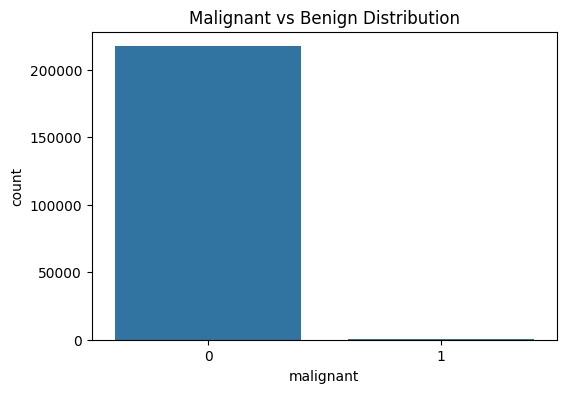

malignant
0    0.998648
1    0.001352
Name: proportion, dtype: float64


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='malignant')
plt.title("Malignant vs Benign Distribution")
plt.show()

print(df['malignant'].value_counts(normalize=True))

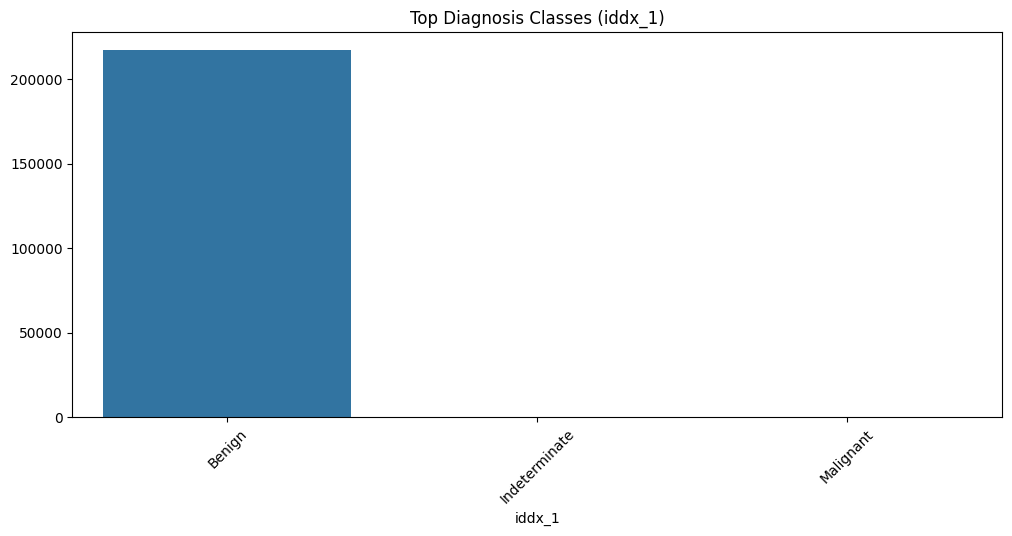

In [8]:
top_diag = df['iddx_1'].value_counts().head(15)

plt.figure(figsize=(12,5))
sns.barplot(x=top_diag.index, y=top_diag.values)
plt.xticks(rotation=45)
plt.title("Top Diagnosis Classes (iddx_1)")
plt.show()

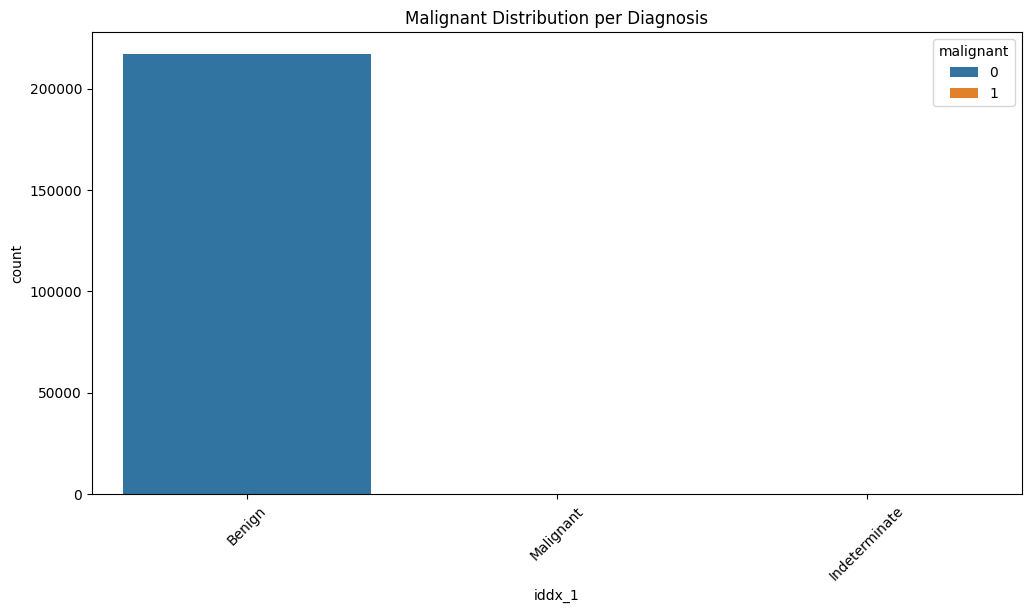

In [9]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='iddx_1', hue='malignant',
              order=df['iddx_1'].value_counts().index[:10])
plt.xticks(rotation=45)
plt.title("Malignant Distribution per Diagnosis")
plt.show()

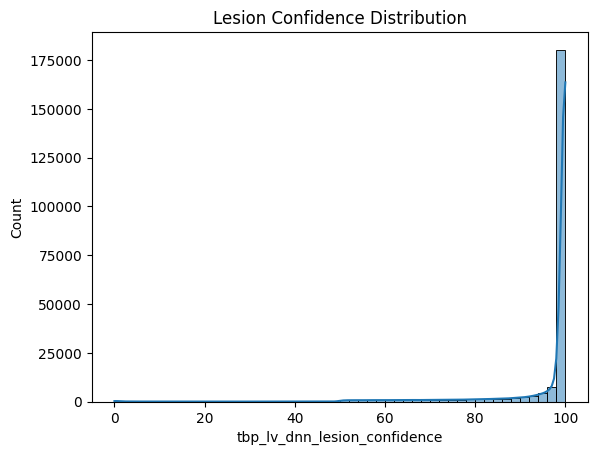

In [10]:
sns.histplot(df['tbp_lv_dnn_lesion_confidence'], bins=50, kde=True)
plt.title("Lesion Confidence Distribution")
plt.show()

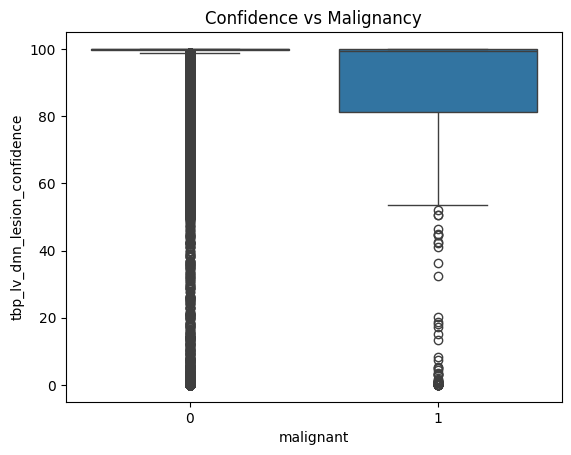

In [11]:
sns.boxplot(data=df, x='malignant', y='tbp_lv_dnn_lesion_confidence')
plt.title("Confidence vs Malignancy")
plt.show()

In [24]:
rare_classes = df['iddx_1'].value_counts()[df['iddx_1'].value_counts() < 105]

print("Rare classes:")
print(rare_classes)

Rare classes:
iddx_1
Indeterminate    100
Name: count, dtype: int64


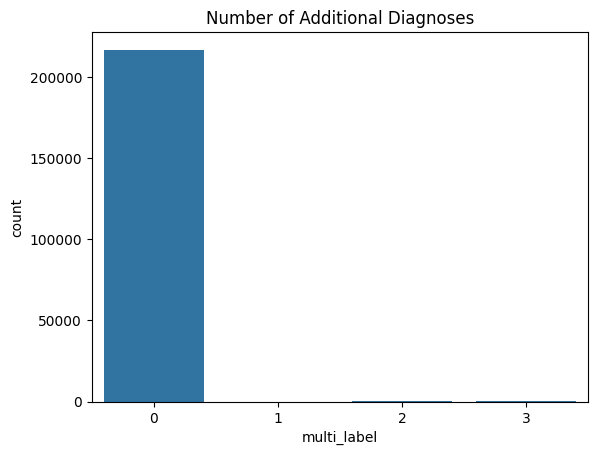

In [14]:
df['multi_label'] = df[['iddx_2','iddx_3','iddx_4']].notnull().sum(axis=1)

sns.countplot(x=df['multi_label'])
plt.title("Number of Additional Diagnoses")
plt.show()

#### Mkaing Subset

In [25]:
malignant_df = df[df['malignant'] == 1]
benign_df = df[df['malignant'] == 0]

n_malignant = len(malignant_df)

In [26]:
n_malignant

294

In [31]:
import pandas as pd

# Separate classes
malignant_df = df[df['malignant'] == 1]
benign_df = df[df['malignant'] == 0]

print("Malignant count:", len(malignant_df))

# Sample equal benign
benign_sampled = benign_df.sample(n=len(malignant_df)+100, random_state=42)

# Combine
subset_df = pd.concat([malignant_df, benign_sampled])

# Shuffle
subset_df = subset_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(subset_df['malignant'].value_counts())

Malignant count: 294
malignant
0    394
1    294
Name: count, dtype: int64


In [32]:
subset_df.to_csv("final_subset_metadata.csv", index=False)

In [33]:
import os
import shutil
from tqdm import tqdm  # optional progress bar

src_folder = r"C:\Users\Xena\OneDrive\Documents\DAU\Advance Image Processing\Skin_Cancer_Detection\data\ISIC_2024_Permissive_Training_Input"
dest_folder = "final_subset_images/"

# Create destination folder
os.makedirs(dest_folder, exist_ok=True)

# Copy images
for img_id in tqdm(subset_df['isic_id']):
    src_path = os.path.join(src_folder, img_id + ".jpg")
    dest_path = os.path.join(dest_folder, img_id + ".jpg")
    
    if os.path.exists(src_path):
        shutil.copy(src_path, dest_path)
    else:
        print(f"Missing: {img_id}")

100%|██████████| 688/688 [00:03<00:00, 203.62it/s]


In [34]:
print("Total images copied:", len(os.listdir(dest_folder)))

Total images copied: 688
